In [1]:
import numpy as np

$$
    T_j(z) = \begin{pmatrix} a_{j,0} & b_{j,0} & 0 & \cdots & \cdots & 0 \\
		0 & a_{j,1} & b_{j,1} & 0 & \ddots & \vdots \\
		\vdots & \ddots & \ddots & \ddots & \ddots & \vdots \\
		\vdots & \ddots & \ddots & \ddots & \ddots & 0 \\
		0 & \cdots & \cdots & 0 & a_{j,p-2} & b_{j,p-2} \\
		b_{j,p-1} z & 0 & \cdots & \cdots & 0 & a_{j,p-1} \end{pmatrix},
		\quad j=0,1, \ldots, p-1,
$$

$$T_j(z) = T(z; a_{j,1}, \dots, a_{j,p-1}, b_{j,1}, \dots, b_{j,p-1})$$

In [2]:
def Tj_matrix(a,b,j,z):
    p = a.shape[0]
    T = np.zeros((p,p), dtype=complex)
    np.fill_diagonal(T, a[j,:])
    T[np.arange(p-1), np.arange(1,p)] = b[j,:-1]
    T[-1,0] = b[j,-1]*z
    return T

$$
    w = \begin{pmatrix} b_{0,p-1} & b_{1,p-1} & \cdots & \cdots & b_{p-2,p-1} & b_{p-1,p-1} \\
        a_{0,p-1} & a_{1,p-1} & \cdots & \cdots & a_{p-2,p-1} & a_{p-1,p-1} \\
		\vdots & \vdots & \vdots & \vdots & \vdots & \vdots \\
		b_{0,0} & b_{1,0} & \cdots & \cdots & b_{p-2,0} & b_{p-1,0} \\
		a_{0,0} & a_{1,0} & \cdots & \cdots & a_{p-2,0} & a_{p-1,0} \end{pmatrix}
$$

In [3]:
def w_matrix(a,b):
    p = a.shape[0]
    w = np.empty((2*p,p), dtype=complex)
    for j in range(p):
        w[2*j] = b[:,p-1-j]
        w[2*j+1] = a[:,p-1-j]
    return w

In [4]:
a = np.array([[1,2,3,4], [5,6,7,8], [9,10,11,12], [13,14,15,16]])
b = np.array([[17,18,19,20], [21,22,23,24], [25,26,27,28], [29,30,31,32]])

print(Tj_matrix(a,b,0,1))
print()
print(w_matrix(a,b))

[[ 1.+0.j 17.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  2.+0.j 18.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  3.+0.j 19.+0.j]
 [20.+0.j  0.+0.j  0.+0.j  4.+0.j]]

[[20.+0.j 24.+0.j 28.+0.j 32.+0.j]
 [ 4.+0.j  8.+0.j 12.+0.j 16.+0.j]
 [19.+0.j 23.+0.j 27.+0.j 31.+0.j]
 [ 3.+0.j  7.+0.j 11.+0.j 15.+0.j]
 [18.+0.j 22.+0.j 26.+0.j 30.+0.j]
 [ 2.+0.j  6.+0.j 10.+0.j 14.+0.j]
 [17.+0.j 21.+0.j 25.+0.j 29.+0.j]
 [ 1.+0.j  5.+0.j  9.+0.j 13.+0.j]]


In [5]:
import RandomTilings as RT

In [6]:
RT.config.log_variant = True

In [7]:
a1 = 0.4
a2 = 0.1

a = np.array([[a1*a2,a1/a2,a1,a1], [a1/a2,a2/a1,a1,1/a1], [a1,a1,a1,a1], [a1,1/a1,a1,1/a1]])
b = np.array([[a1,1/a1,a1,1/a1], [a1,a1,a1,a1], [a1,1/a1,a1,1/a1], [a1,a1,a1,a1]])

w = w_matrix(a,b)

w_direct = np.array([[1/a1,a1,1/a1,a1], [a1,1/a1,a1,1/a1], [a1,a1,a1,a1], [a1,a1,a1,a1],
              [1/a1,a1,1/a1,a1], [a1/a2,a2/a1,a1,1/a1], [a1,a1,a1,a1], [a1*a2,a1/a2,a1,a1]])

print(w == w_direct)

[[ True  True  True  True]
 [ True  True  True  True]
 [ True  True  True  True]
 [ True  True  True  True]
 [ True  True  True  True]
 [ True  True  True  True]
 [ True  True  True  True]
 [ True  True  True  True]]


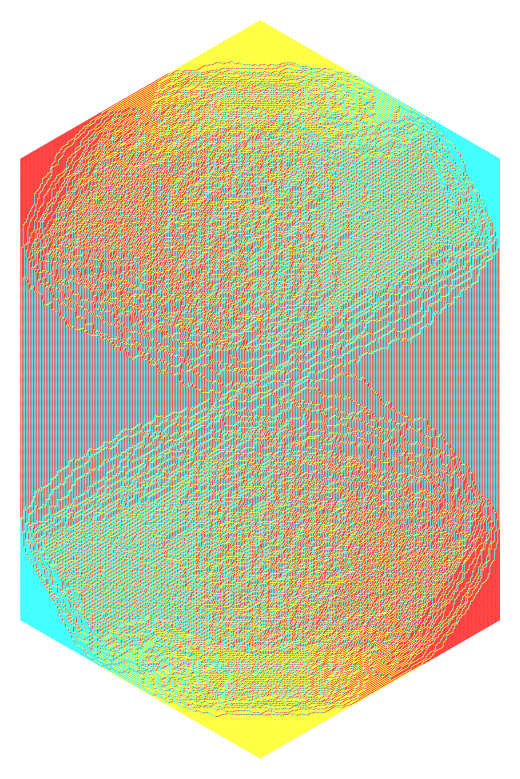

In [15]:
n = 500
bc = 0.6

H = RT.Hexagon(n,w,1,bc,bc)
H.shuffle()
H.plot(dpi=200)